# Assignment 3 - Classification Models and Evaluation

- **Course:** MBAI 5310G: AI Programming - Ontario Tech University
- **Dataset:** E-commerce Customer Churn Dataset
- **Target:** 'Churned' (Yes / No) - Binary Classification

This notebook trains and compares two classification models: **Logistic Regression** and **SVM** on the e-commerce customer churn dataset, and evaluates them using standard classification metrics.

## Step 1: Understand the ML Problem

- **Task:** Supervised binary classification.
- **Target:** 'Churned' - 'Yes' (customer churned) or 'No' (still active).
- **Goal:** Predict whether a customer will churn from their attributes and behaviour, so the business can target retention efforts.

In [1]:
import pandas as pd
from pathlib import Path

file_name = "ecommerce_customer_churn_dataset.csv"
data_path = Path(file_name)

print("Current dataset path:", data_path)
print("File exists:", data_path.exists())

df = pd.read_csv(data_path)
print("Dataset loaded successfully!")
df.head()

Current dataset path: ecommerce_customer_churn_dataset.csv
File exists: True
Dataset loaded successfully!


,Customer_ID,Age,Gender,Region,Membership_Type,Monthly_Spending,Number_of_Orders,Days_Since_Last_Purchase,Customer_Support_Calls,Average_Rating,Used_Coupon,Newsletter_Subscribed,Device_Type,Churned
0,1,37.0,Female,Manitoba,Platinum,332.0,1,218,7,1.0,No,No,Mobile,Yes
1,2,41.0,Female,Manitoba,Silver,632.0,11,199,3,3.0,No,Yes,Desktop,No
2,3,30.0,Male,British Columbia,Platinum,972.0,16,258,2,4.0,No,No,Tablet,No
3,4,58.0,Female,Manitoba,Basic,752.0,10,197,8,5.0,No,No,Mobile,Yes
4,5,59.0,Male,Quebec,Silver,619.0,12,81,3,4.0,No,Yes,Mobile,No


In [2]:
target_column = "Churned"
print("Target column:", target_column)

print("\nTarget values:")
print(df[target_column].value_counts())

Target column: Churned

Target values:
Churned
No     238
Yes     87
Name: count, dtype: int64


In [3]:
feature_columns = [
    "Age", "Gender", "Region", "Membership_Type",
    "Monthly_Spending", "Number_of_Orders", "Days_Since_Last_Purchase",
    "Customer_Support_Calls", "Average_Rating",
    "Used_Coupon", "Newsletter_Subscribed", "Device_Type"
]

X = df[feature_columns]
y = df[target_column]

print("Feature columns:", feature_columns)
print("\nTarget column:", target_column)
print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Feature columns: ['Age', 'Gender', 'Region', 'Membership_Type', 'Monthly_Spending', 'Number_of_Orders', 'Days_Since_Last_Purchase', 'Customer_Support_Calls', 'Average_Rating', 'Used_Coupon', 'Newsletter_Subscribed', 'Device_Type']

Target column: Churned

Shape of X: (325, 12)
Shape of y: (325,)


## Step 2: Initial Data Inspection

Check the dataset's shape, columns, data types, missing values, and duplicates.

In [4]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst five rows:")
display(df.head())

Dataset shape: (325, 14)

Column names:
['Customer_ID', 'Age', 'Gender', 'Region', 'Membership_Type', 'Monthly_Spending', 'Number_of_Orders', 'Days_Since_Last_Purchase', 'Customer_Support_Calls', 'Average_Rating', 'Used_Coupon', 'Newsletter_Subscribed', 'Device_Type', 'Churned']

First five rows:


,Customer_ID,Age,Gender,Region,Membership_Type,Monthly_Spending,Number_of_Orders,Days_Since_Last_Purchase,Customer_Support_Calls,Average_Rating,Used_Coupon,Newsletter_Subscribed,Device_Type,Churned
0,1,37.0,Female,Manitoba,Platinum,332.0,1,218,7,1.0,No,No,Mobile,Yes
1,2,41.0,Female,Manitoba,Silver,632.0,11,199,3,3.0,No,Yes,Desktop,No
2,3,30.0,Male,British Columbia,Platinum,972.0,16,258,2,4.0,No,No,Tablet,No
3,4,58.0,Female,Manitoba,Basic,752.0,10,197,8,5.0,No,No,Mobile,Yes
4,5,59.0,Male,Quebec,Silver,619.0,12,81,3,4.0,No,Yes,Mobile,No


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 325 entries, 0 to 324
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               325 non-null    int64  
 1   Age                       320 non-null    float64
 2   Gender                    320 non-null    str    
 3   Region                    320 non-null    str    
 4   Membership_Type           320 non-null    str    
 5   Monthly_Spending          320 non-null    float64
 6   Number_of_Orders          325 non-null    int64  
 7   Days_Since_Last_Purchase  325 non-null    int64  
 8   Customer_Support_Calls    325 non-null    int64  
 9   Average_Rating            320 non-null    float64
 10  Used_Coupon               325 non-null    str    
 11  Newsletter_Subscribed     325 non-null    str    
 12  Device_Type               325 non-null    str    
 13  Churned                   325 non-null    str    
dtypes: float64(3), int64(

In [6]:
print("Data types:")
print(df.dtypes)

Data types:
Customer_ID                   int64
Age                         float64
Gender                          str
Region                          str
Membership_Type                 str
Monthly_Spending            float64
Number_of_Orders              int64
Days_Since_Last_Purchase      int64
Customer_Support_Calls        int64
Average_Rating              float64
Used_Coupon                     str
Newsletter_Subscribed           str
Device_Type                     str
Churned                         str
dtype: object


In [7]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Customer_ID                 0
Age                         5
Gender                      5
Region                      5
Membership_Type             5
Monthly_Spending            5
Number_of_Orders            0
Days_Since_Last_Purchase    0
Customer_Support_Calls      0
Average_Rating              5
Used_Coupon                 0
Newsletter_Subscribed       0
Device_Type                 0
Churned                     0
dtype: int64


In [8]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 5


## Step 3: Data Cleaning

Remove duplicate rows, then fill missing values (median for numerical columns, mode for categorical columns).

In [9]:
df_clean = df.copy()
print("Original shape:", df_clean.shape)
print("Duplicates before cleaning:", df_clean.duplicated().sum())

Original shape: (325, 14)
Duplicates before cleaning: 5


In [10]:
df_clean = df_clean.drop_duplicates()
print("Shape after removing duplicates:", df_clean.shape)
print("Duplicates after cleaning:", df_clean.duplicated().sum())

Shape after removing duplicates: (320, 14)
Duplicates after cleaning: 0


In [11]:
print("Missing values before filling:")
print(df_clean.isnull().sum())

Missing values before filling:
Customer_ID                 0
Age                         5
Gender                      5
Region                      5
Membership_Type             5
Monthly_Spending            5
Number_of_Orders            0
Days_Since_Last_Purchase    0
Customer_Support_Calls      0
Average_Rating              5
Used_Coupon                 0
Newsletter_Subscribed       0
Device_Type                 0
Churned                     0
dtype: int64


In [12]:
numeric_columns = [
    "Age", "Monthly_Spending", "Number_of_Orders",
    "Days_Since_Last_Purchase", "Customer_Support_Calls", "Average_Rating"
]

categorical_columns = [
    "Gender", "Region", "Membership_Type",
    "Used_Coupon", "Newsletter_Subscribed", "Device_Type"
]

In [13]:
for column in numeric_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())

In [14]:
for column in categorical_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].mode()[0])

In [15]:
print("Missing values after cleaning:")
print(df_clean.isnull().sum())

print("\nCleaned dataset preview:")
display(df_clean.head())

Missing values after cleaning:
Customer_ID                 0
Age                         0
Gender                      0
Region                      0
Membership_Type             0
Monthly_Spending            0
Number_of_Orders            0
Days_Since_Last_Purchase    0
Customer_Support_Calls      0
Average_Rating              0
Used_Coupon                 0
Newsletter_Subscribed       0
Device_Type                 0
Churned                     0
dtype: int64

Cleaned dataset preview:


,Customer_ID,Age,Gender,Region,Membership_Type,Monthly_Spending,Number_of_Orders,Days_Since_Last_Purchase,Customer_Support_Calls,Average_Rating,Used_Coupon,Newsletter_Subscribed,Device_Type,Churned
0,1,37.0,Female,Manitoba,Platinum,332.0,1,218,7,1.0,No,No,Mobile,Yes
1,2,41.0,Female,Manitoba,Silver,632.0,11,199,3,3.0,No,Yes,Desktop,No
2,3,30.0,Male,British Columbia,Platinum,972.0,16,258,2,4.0,No,No,Tablet,No
3,4,58.0,Female,Manitoba,Basic,752.0,10,197,8,5.0,No,No,Mobile,Yes
4,5,59.0,Male,Quebec,Silver,619.0,12,81,3,4.0,No,Yes,Mobile,No


## Step 4: Define Features and Target

Use all customer attributes as features (excluding `Customer_ID`) and convert the target from text labels (`Yes`/`No`) to numerical labels (`1`/`0`).

In [16]:
X = df_clean[feature_columns]
y = df_clean[target_column]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (320, 12)
Shape of y: (320,)


In [17]:
print("Target value counts before conversion:")
print(y.value_counts())

Target value counts before conversion:
Churned
No     233
Yes     87
Name: count, dtype: int64


In [18]:
y = y.map({"No": 0, "Yes": 1})

print("Target value counts after conversion:")
print(y.value_counts())

Target value counts after conversion:
Churned
0    233
1     87
Name: count, dtype: int64


## Step 5: Train/Test Split

80% training, 20% testing. The split is stratified by the target to preserve class proportions in both sets.

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (256, 12)
Shape of X_test: (64, 12)
Shape of y_train: (256,)
Shape of y_test: (64,)


In [20]:
print("Target distribution in y_train:")
print(y_train.value_counts())

print("\nTarget distribution in y_test:")
print(y_test.value_counts())

Target distribution in y_train:
Churned
0    186
1     70
Name: count, dtype: int64

Target distribution in y_test:
Churned
0    47
1    17
Name: count, dtype: int64


## Step 6: Preprocessing

Scale numerical features with `StandardScaler` and one-hot encode categorical features. The `ColumnTransformer` is fit on training data only to prevent data leakage, then applied to the test data.

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    "Age", "Monthly_Spending", "Number_of_Orders",
    "Days_Since_Last_Purchase", "Customer_Support_Calls", "Average_Rating"
]

categorical_features = [
    "Gender", "Region", "Membership_Type",
    "Used_Coupon", "Newsletter_Subscribed", "Device_Type"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [22]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
print("X_train preprocessing completed!")

X_train preprocessing completed!


In [23]:
X_test_preprocessed = preprocessor.transform(X_test)
print("X_test preprocessing completed!")

X_test preprocessing completed!


In [24]:
print("Preprocessing shape summary:")
print("X_train before:", X_train.shape)
print("X_train after: ", X_train_preprocessed.shape)
print("X_test before: ", X_test.shape)
print("X_test after:  ", X_test_preprocessed.shape)

Preprocessing shape summary:
X_train before: (256, 12)
X_train after:  (256, 24)
X_test before:  (64, 12)
X_test after:   (64, 24)


## Step 7: Baseline Model - Logistic Regression

Train a Logistic Regression model on the preprocessed training data and generate predictions for the test set.

In [25]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train_preprocessed, y_train)
print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [26]:
y_pred_logistic = logistic_model.predict(X_test_preprocessed)
print("Predictions completed successfully!")

Predictions completed successfully!


In [27]:
print("First 10 predictions:")
print(y_pred_logistic[:10])

First 10 predictions:
[1 0 0 0 0 0 0 0 0 0]


In [28]:
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_logistic
})
display(comparison_df.head(10))

,Actual,Predicted
0,0,1
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,1,0
8,0,0
9,0,0


## Step 8: Evaluate Logistic Regression

Compute the confusion matrix and the four standard classification metrics: accuracy, precision, recall, F1-score and print the classification report.

In [29]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report
)
import matplotlib.pyplot as plt

In [30]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)
print("Confusion Matrix:")
print(cm_logistic)

Confusion Matrix:
[[43  4]
 [ 6 11]]


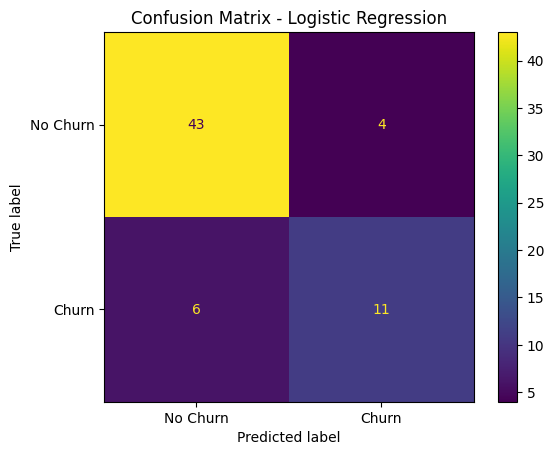

In [31]:
display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["No Churn", "Churn"]
)
display_cm.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [32]:
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic, zero_division=0)
recall_logistic = recall_score(y_test, y_pred_logistic, zero_division=0)
f1_logistic = f1_score(y_test, y_pred_logistic, zero_division=0)

print("Logistic Regression Evaluation Metrics:")
print("Accuracy:", accuracy_logistic)
print("Precision:", precision_logistic)
print("Recall:", recall_logistic)
print("F1-score:", f1_logistic)

Logistic Regression Evaluation Metrics:
Accuracy: 0.84375
Precision: 0.7333333333333333
Recall: 0.6470588235294118
F1-score: 0.6875


In [33]:
print("Classification Report - Logistic Regression:")
print(classification_report(y_test, y_pred_logistic, target_names=["No Churn", "Churn"], zero_division=0))

Classification Report - Logistic Regression:


              precision    recall  f1-score   support

    No Churn       0.88      0.91      0.90        47
       Churn       0.73      0.65      0.69        17

    accuracy                           0.84        64
   macro avg       0.81      0.78      0.79        64
weighted avg       0.84      0.84      0.84        64



## Step 9: Comparison Model - SVM

Train an SVM classifier on the same preprocessed training data so it can be compared fairly with Logistic Regression. 'probability=True' is set so predicted probabilities are available later.

In [34]:
from sklearn.svm import SVC

svm_model = SVC(random_state=42, probability=True)
svm_model.fit(X_train_preprocessed, y_train)
print("SVM model trained successfully!")

SVM model trained successfully!


In [35]:
y_pred_svm = svm_model.predict(X_test_preprocessed)
print("SVM predictions completed successfully!")

SVM predictions completed successfully!


In [36]:
print("First 10 SVM predictions:")
print(y_pred_svm[:10])

First 10 SVM predictions:
[1 0 0 0 0 0 0 0 0 0]


In [37]:
svm_comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "SVM_Predicted": y_pred_svm
})
display(svm_comparison_df.head(10))

,Actual,SVM_Predicted
0,0,1
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,1,0
8,0,0
9,0,0


## Step 10: Evaluate SVM and Compare with Logistic Regression

Compute the same metrics for SVM, then build a side-by-side comparison table and bar chart.

In [38]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, zero_division=0)
recall_svm = recall_score(y_test, y_pred_svm, zero_division=0)
f1_svm = f1_score(y_test, y_pred_svm, zero_division=0)

print("SVM Evaluation Metrics:")
print("Accuracy:", accuracy_svm)
print("Precision:", precision_svm)
print("Recall:", recall_svm)
print("F1-score:", f1_svm)

SVM Evaluation Metrics:
Accuracy: 0.875
Precision: 0.9090909090909091
Recall: 0.5882352941176471
F1-score: 0.7142857142857143


In [39]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix - SVM:")
print(cm_svm)

Confusion Matrix - SVM:
[[46  1]
 [ 7 10]]


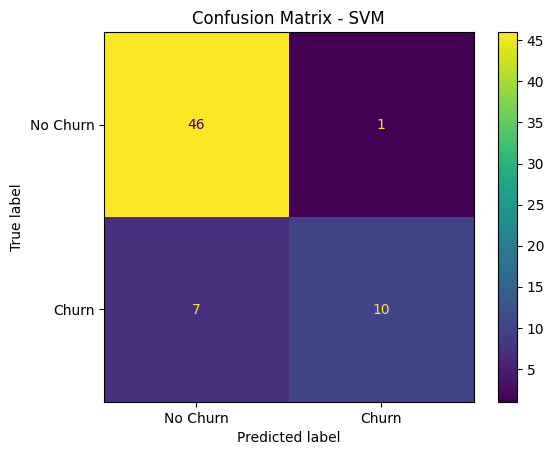

In [40]:
display_cm_svm = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["No Churn", "Churn"]
)
display_cm_svm.plot()
plt.title("Confusion Matrix - SVM")
plt.show()

In [41]:
print("Classification Report - SVM:")
print(classification_report(y_test, y_pred_svm, target_names=["No Churn", "Churn"], zero_division=0))

Classification Report - SVM:
              precision    recall  f1-score   support

    No Churn       0.87      0.98      0.92        47
       Churn       0.91      0.59      0.71        17

    accuracy                           0.88        64
   macro avg       0.89      0.78      0.82        64
weighted avg       0.88      0.88      0.87        64



In [42]:
model_comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM"],
    "Accuracy": [accuracy_logistic, accuracy_svm],
    "Precision": [precision_logistic, precision_svm],
    "Recall": [recall_logistic, recall_svm],
    "F1-score": [f1_logistic, f1_svm]
})
display(model_comparison_df)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.84375,0.733333,0.647059,0.687500
1,SVM,0.87500,0.909091,0.588235,0.714286


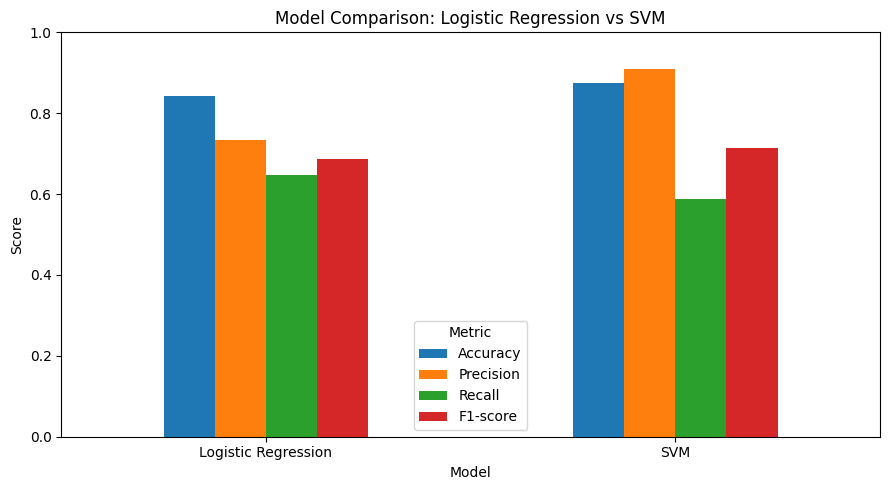

In [43]:
model_comparison_df.set_index("Model").plot(kind="bar", figsize=(9, 5))
plt.title("Model Comparison: Logistic Regression vs SVM")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## Step 11: Interpret Classification Outputs

Logistic Regression produces both class predictions and predicted probabilities. Examining the probabilities (alongside the 0.50 decision threshold) shows how confident the model is on each test customer.

In [44]:
y_prob_logistic = logistic_model.predict_proba(X_test_preprocessed)
prob_no_churn = y_prob_logistic[:, 0]
prob_churn = y_prob_logistic[:, 1]

print("Predicted probabilities created successfully.")

Predicted probabilities created successfully.


In [45]:
classification_output_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_logistic,
    "Probability_No_Churn": prob_no_churn.round(3),
    "Probability_Churn": prob_churn.round(3)
})
display(classification_output_df.head(15))

,Actual,Predicted,Probability_No_Churn,Probability_Churn
0,0,1,0.426,0.574
1,0,0,0.946,0.054
2,0,0,0.981,0.019
3,0,0,0.998,0.002
4,0,0,0.996,0.004
5,0,0,0.979,0.021
6,0,0,0.550,0.450
7,1,0,0.958,0.042
8,0,0,0.991,0.009
9,0,0,0.984,0.016


In [46]:
classification_output_df["Actual_Label"] = classification_output_df["Actual"].map({0: "No Churn", 1: "Churn"})
classification_output_df["Predicted_Label"] = classification_output_df["Predicted"].map({0: "No Churn", 1: "Churn"})
display(classification_output_df.head(15))

,Actual,Predicted,Probability_No_Churn,Probability_Churn,Actual_Label,Predicted_Label
0,0,1,0.426,0.574,No Churn,Churn
1,0,0,0.946,0.054,No Churn,No Churn
2,0,0,0.981,0.019,No Churn,No Churn
3,0,0,0.998,0.002,No Churn,No Churn
4,0,0,0.996,0.004,No Churn,No Churn
5,0,0,0.979,0.021,No Churn,No Churn
6,0,0,0.550,0.450,No Churn,No Churn
7,1,0,0.958,0.042,Churn,No Churn
8,0,0,0.991,0.009,No Churn,No Churn
9,0,0,0.984,0.016,No Churn,No Churn


In [47]:
classification_output_df["Decision_Explanation"] = classification_output_df["Probability_Churn"].apply(
    lambda p: "Predicted Churn because probability is 0.50 or higher"
              if p >= 0.50
              else "Predicted No Churn because probability is below 0.50"
)
display(classification_output_df.head(15))

,Actual,Predicted,Probability_No_Churn,Probability_Churn,Actual_Label,Predicted_Label,Decision_Explanation
0,0,1,0.426,0.574,No Churn,Churn,Predicted Churn because probability is 0.50 or...
1,0,0,0.946,0.054,No Churn,No Churn,Predicted No Churn because probability is belo...
2,0,0,0.981,0.019,No Churn,No Churn,Predicted No Churn because probability is belo...
3,0,0,0.998,0.002,No Churn,No Churn,Predicted No Churn because probability is belo...
4,0,0,0.996,0.004,No Churn,No Churn,Predicted No Churn because probability is belo...
5,0,0,0.979,0.021,No Churn,No Churn,Predicted No Churn because probability is belo...
6,0,0,0.550,0.450,No Churn,No Churn,Predicted No Churn because probability is belo...
7,1,0,0.958,0.042,Churn,No Churn,Predicted No Churn because probability is belo...
8,0,0,0.991,0.009,No Churn,No Churn,Predicted No Churn because probability is belo...
9,0,0,0.984,0.016,No Churn,No Churn,Predicted No Churn because probability is belo...


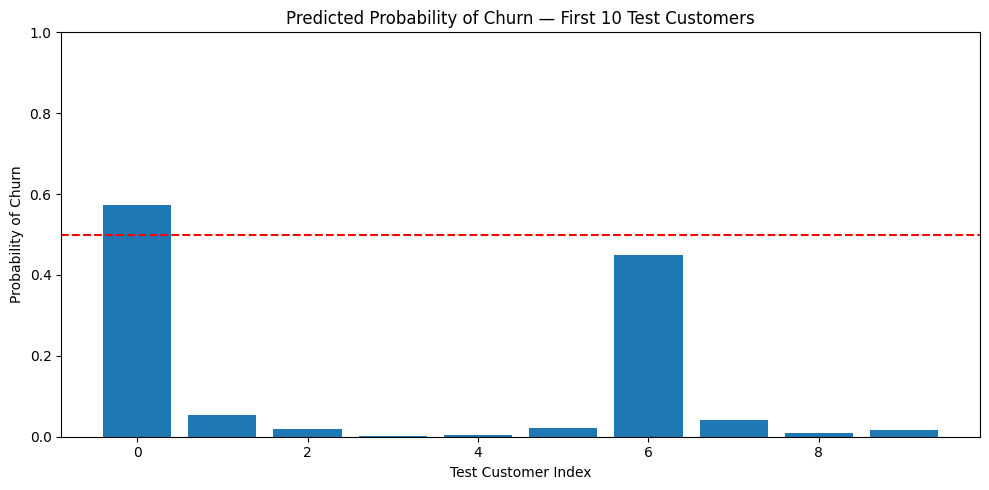

In [48]:
first_10_outputs = classification_output_df.head(10)
plt.figure(figsize=(10, 5))
plt.bar(first_10_outputs.index, first_10_outputs["Probability_Churn"])
plt.axhline(y=0.50, linestyle="--", color="red")
plt.ylim(0, 1)
plt.title("Predicted Probability of Churn — First 10 Test Customers")
plt.xlabel("Test Customer Index")
plt.ylabel("Probability of Churn")
plt.tight_layout()
plt.show()

## Step 12: Final Interpretation and Business Conclusion

Compare both models on F1-score and select the better one. F1-score is used as the tie-breaker because it balances precision (avoiding false alarms) and recall (catching real churners), which matters under the class imbalance in this dataset.

In [49]:
print("Final Model Comparison Table:")
display(model_comparison_df)

Final Model Comparison Table:


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.84375,0.733333,0.647059,0.687500
1,SVM,0.87500,0.909091,0.588235,0.714286


In [50]:
best_model_row = model_comparison_df.loc[model_comparison_df["F1-score"].idxmax()]
best_model_name = best_model_row["Model"]
best_f1_score = best_model_row["F1-score"]

print("Best model based on F1-score:")
print(best_model_name)

print("\nBest F1-score:")
print(best_f1_score)

Best model based on F1-score:
SVM

Best F1-score:
0.7142857142857143


In [51]:
print("Final Conclusion:")
print(f"Based on the F1-score, the better model for this dataset is {best_model_name}.")
print("This model gives the best balance between precision and recall.")
print("However, the final model choice should also depend on the business goal.")

Final Conclusion:
Based on the F1-score, the better model for this dataset is SVM.
This model gives the best balance between precision and recall.
However, the final model choice should also depend on the business goal.


**Business interpretation:** SVM wins on F1 due to a precision boost (≈ 0.91 vs ≈ 0.73), meaning fewer false-alarm retention campaigns. Logistic Regression gives a small edge on recall and is easier to explain. The final operational choice depends on whether the business cares more about avoiding wasted retention spend (precision - SVM) or catching the maximum number of churners (recall - Logistic Regression).

## Step 13: Responsible AI Reflection

Inspect class imbalance and misclassifications to understand where and how the model fails.

In [52]:
print("Target distribution in the full cleaned dataset:")
print(y.value_counts())

print("\nTarget distribution as percentage:")
print(y.value_counts(normalize=True) * 100)

Target distribution in the full cleaned dataset:
Churned
0    233
1     87
Name: count, dtype: int64

Target distribution as percentage:
Churned
0    72.8125
1    27.1875
Name: proportion, dtype: float64


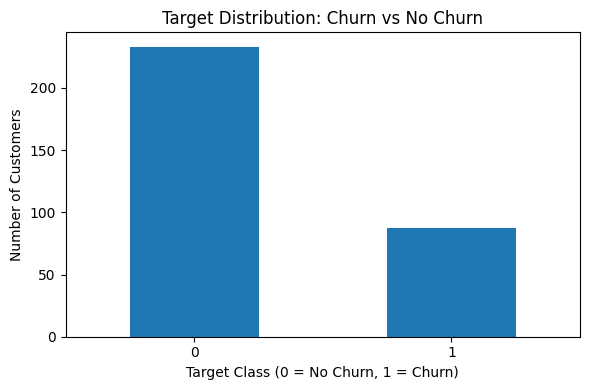

In [53]:
y.value_counts().plot(kind="bar", figsize=(6, 4))
plt.title("Target Distribution: Churn vs No Churn")
plt.xlabel("Target Class (0 = No Churn, 1 = Churn)")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [54]:
error_analysis_df = classification_output_df.copy()
error_analysis_df["Correct_Prediction"] = error_analysis_df["Actual"] == error_analysis_df["Predicted"]

incorrect_predictions_df = error_analysis_df[error_analysis_df["Correct_Prediction"] == False]

print("Number of incorrect predictions:", len(incorrect_predictions_df))
display(incorrect_predictions_df.head(10))

Number of incorrect predictions: 10


,Actual,Predicted,Probability_No_Churn,Probability_Churn,Actual_Label,Predicted_Label,Decision_Explanation,Correct_Prediction
0,0,1,0.426,0.574,No Churn,Churn,Predicted Churn because probability is 0.50 or...,False
7,1,0,0.958,0.042,Churn,No Churn,Predicted No Churn because probability is belo...,False
14,0,1,0.469,0.531,No Churn,Churn,Predicted Churn because probability is 0.50 or...,False
28,0,1,0.276,0.724,No Churn,Churn,Predicted Churn because probability is 0.50 or...,False
33,1,0,0.605,0.395,Churn,No Churn,Predicted No Churn because probability is belo...,False
37,1,0,0.901,0.099,Churn,No Churn,Predicted No Churn because probability is belo...,False
39,1,0,0.882,0.118,Churn,No Churn,Predicted No Churn because probability is belo...,False
51,0,1,0.375,0.625,No Churn,Churn,Predicted Churn because probability is 0.50 or...,False
56,1,0,0.985,0.015,Churn,No Churn,Predicted No Churn because probability is belo...,False
60,1,0,0.830,0.170,Churn,No Churn,Predicted No Churn because probability is belo...,False


**Reflection.** The dataset is imbalanced (≈73% No / ≈27% Yes), so accuracy alone overstates performance. F1 and recall on the minority class are more honest measures. False positives cost retention budget; false negatives mean missing real churners. The dataset contains personal attributes ('Age', 'Gender', 'Region', 'spending'), which raise privacy and fairness concerns: predictions should be reviewed before driving decisions, and the model should support, not replace human judgment.

## Save Output Files

Save the cleaned dataset, the model comparison table, and the classification outputs as CSV files.

In [55]:
from pathlib import Path

output_folder = Path("outputs")
output_folder.mkdir(exist_ok=True)
print("Output folder is ready.")

Output folder is ready.


In [56]:
cleaned_data_path = output_folder / "cleaned_ecommerce_customer_churn_dataset.csv"
df_clean.to_csv(cleaned_data_path, index=False)
print("Cleaned dataset saved:", cleaned_data_path)

Cleaned dataset saved: outputs/cleaned_ecommerce_customer_churn_dataset.csv


In [57]:
model_results_path = output_folder / "model_comparison_results.csv"
model_comparison_df.to_csv(model_results_path, index=False)
print("Model comparison results saved:", model_results_path)

Model comparison results saved: outputs/model_comparison_results.csv


In [58]:
classification_output_path = output_folder / "classification_outputs.csv"
classification_output_df.to_csv(classification_output_path, index=False)
print("Classification outputs saved:", classification_output_path)

Classification outputs saved: outputs/classification_outputs.csv


## Summary

| Model | Accuracy | Precision | Recall | F1-score |
|---|---:|---:|---:|---:|
| Logistic Regression | 0.844 | 0.733 | 0.647 | 0.688 |
| **SVM** | **0.875** | **0.909** | 0.588 | **0.714** |

**Selected model:** SVM (best F1-score). The trade-off is higher precision and accuracy at the cost of slightly lower recall.

## Final Explanation

**Which model performed better?** **SVM** outperformed Logistic Regression on F1-score (**0.714 vs 0.688**), accuracy (**0.875 vs 0.844**), and precision (**0.909 vs 0.733**). Logistic Regression edged out SVM only on recall (0.647 vs 0.588). Because F1 was the tie-breaker chosen for this imbalanced problem, **SVM is the selected model**.

**Which metric is most important?** For customer churn, **F1-score** is the most useful single number because:
- The classes are imbalanced (≈73% No / ≈27% Yes), so accuracy alone is misleading - a "predict everyone stays" model would still score ≈73%.
- The business cares about both catching real churners (**recall**) and not wasting retention budget on customers who would have stayed anyway (**precision**).
- F1 balances the two and is therefore the most honest summary metric here.

In practice, the right metric depends on the cost of action: if retention offers are cheap, prioritise recall; if they are expensive (e.g., aggressive discounts), prioritise precision.

**What do false positives and false negatives mean in this dataset?**
- **False positive:** the model predicts a customer will churn, but they actually stay. *Consequence:* wasted retention spend and possibly annoying loyal customers with unnecessary discount offers.
- **False negative:** the model predicts a customer is loyal, but they actually churn. *Consequence:* a missed save opportunity and permanently lost revenue.

False negatives are usually more costly because losing a customer is hard to reverse, while a false positive only wastes a small marketing cost.

**One possible limitation or bias.** Demographic features ('Age', 'Gender', 'Region') directly influence the prediction. If the training data over- or under-represents any group, the model can systematically over- or under-predict churn for that group, leading to unfair treatment in retention campaigns. The dataset is also small (≈320 rows), which limits statistical reliability and increases the variance of the estimates.

**Why human judgment is still needed.**
- Predictions are estimates, not guarantees, so even a high probability can be wrong.
- The dataset does not capture important context, such as VIP status, a recent complaint, or a known service outage that a human account manager would know about.
- Retention decisions have ethical and financial consequences, including privacy and fairness considerations that a model cannot reason about on its own.
- The model should be used as a **decision-support tool** that flags at-risk customers for review, not as an automatic decision-maker.